In [1]:
from langchain_ollama import ChatOllama

# Create BioMistral LLM
llm = ChatOllama(
    model="hf.co/BioMistral/BioMistral-7B-GGUF:latest"
)






In [2]:
from pydantic import BaseModel, Field
from typing import Optional



class ForecastSt(BaseModel):
    heart_rate: float
    sbp: float
    dbp: float
    mbp: float
    temperature: float
    sbp_ni:float
    dbp_ni:float
    mbp_ni:float
    spO2: float
    glucose: float
    sofa_24_hours:float
    model_config = {
        "extra": "forbid"
    }



class ForecastOutput(BaseModel):
    forecasted_vitals: ForecastSt
    model_config = {
        "extra": "forbid"
    }


class OutcomesSt(BaseModel):
    discharge_outcome:bool
    icuouttime_outcome:bool
    death_outcome:bool
    sepsis_outcome:bool
    los_outcome:float
    model_config = {
        "extra": "forbid"
    }

class OutcomeOutput(BaseModel):
    outcome:OutcomesSt
    model_config = {
        "extra": "forbid"
    }

import operator
from typing import Annotated, Dict, Optional
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage

In [3]:
class OverallState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

    # =========================
    # Original inputs (raw data)
    # =========================
    original_static:Dict[str,str]

    original_vitals: Dict[str, float]

    original_labs: Dict[str, float]

    original_gcs: Dict[str, float]

    original_ventilator: Dict[str, float]

    original_interventions: Dict[str, int]

    original_outcomes: Dict[str, float]

    #---------------------------
    #Previous values
    #--------------------------
    previous_forecasted_vitals: Optional[ForecastSt]
    previous_clinical_summary: Optional[str]
    previous_outcomes: Optional[OutcomesSt]

    # =========================
    # LLM structured outputs
    # =========================



    forecasted_vitals: Optional[ForecastSt]

    clinical_summary: Optional[str]

    outcomes: Optional[OutcomesSt]

    recommended_ventilator_changes: Optional[Dict[str, float]]

    recommended_interventions: Optional[Dict[str, int]]


    improvement_detected: Optional[bool]


    severity_scores: Optional[Dict[str, float]]

    detected_syndromes: Optional[Dict[str, bool]]

    selected_protocols: Optional[Dict[str, str]]

    escalation_decision: Optional[Dict[str, int]]  
    weaning_recommendation: Optional[Dict[str, int]] 
    



outcome_model = llm.with_structured_output(OutcomeOutput)
forecast_model = llm.with_structured_output(ForecastOutput)

In [4]:
from typing import Literal
from langchain_core.messages import SystemMessage, HumanMessage
def start_agent(state: OverallState):
    return {}
def forecast_agent(state: OverallState):

    
    previous_forecast = state.get("forecasted_vitals")

    system_prompt = SystemMessage(
        content=(
            "You are an ICU physiological forecasting agent. "
            "Predict the patient's future vital signs based on current vitals, labs, ventilator settings, and interventions. "
            "Forecast realistic ICU physiological values for the next monitoring interval. "
            "Do not hallucinate parameters. Only use defined vital fields."
        )
    )

    human_prompt = HumanMessage(
        content=f"""
        static variables:{state['original_static']}
        Current vitals: {state['original_vitals']}
        Labs: {state['original_labs']}
        GCS: {state['original_gcs']}
        Ventilator: {state['original_ventilator']}
        Interventions: {state['original_interventions']}
        """
    )

    structured = forecast_model.invoke([system_prompt, human_prompt])

    return {
        "previous_forecasted_vitals": previous_forecast,
        "forecasted_vitals": structured.forecasted_vitals,

    }


def prediction_agent(state: OverallState):

    previous_outcomes = state.get("outcomes")

    system_prompt = SystemMessage(
        content=(
            "You are an ICU clinical prediction agent. "
            "Analyze patient vitals, labs, ventilator settings, and interventions. "
            "Predict the following outcomes:\n"
            "- discharge_outcome (True if likely discharge)\n"
            "- icuouttime_outcome (True if ICU exit likely)\n"
            "- death_outcome (True if mortality risk high)\n"
            "- sepsis_outcome (True if sepsis likely)\n"
            "- los_outcome (predicted ICU length of stay in hours)\n"
            "Be medically realistic and conservative."
        )
    )

    human_prompt = HumanMessage(
        content=f"""
        static variables:{state['original_static']}
        Vitals: {state['original_vitals']}
        Labs: {state['original_labs']}
        GCS: {state['original_gcs']}
        Ventilator: {state['original_ventilator']}
        Interventions: {state['original_interventions']}
        """
    )



    structured = outcome_model.invoke([system_prompt, human_prompt])

    return {
    "previous_outcomes": previous_outcomes,
    "outcomes": structured.outcome,

   
    }




def summarization_agent(state: OverallState):

    previous_summary = state.get("clinical_summary")

    system_prompt = SystemMessage(
        content=(
            "You are an ICU clinical reasoning agent. "
            "Summarize the patient's CURRENT physiological condition only. "
            "Do NOT use predictions or forecasted values."
        )
    )

    human_prompt = HumanMessage(
        content=f"""
        static variables:{state['original_static']}
        Current vitals: {state['original_vitals']}
        Labs: {state['original_labs']}
        GCS: {state['original_gcs']}
        Ventilator: {state['original_ventilator']}
        Interventions: {state['original_interventions']}
        """
    )

    response = llm.invoke([system_prompt, human_prompt])

    return {
        "previous_clinical_summary": previous_summary,
        "clinical_summary": response.content
    }


def severity_scoring_agent(state: OverallState):

    forecast = state.get("forecasted_vitals")
    labs = state.get("original_labs")
    gcs = state.get("original_gcs")
    vent = state.get("original_ventilator")

    if forecast is None:
        return {}

    scores = {}

   
    if forecast.sbp > 0:
        scores["shock_index"] = forecast.heart_rate / forecast.sbp
    else:
        scores["shock_index"] = 0


    scores["hypotension"] = forecast.mbp < 65


    
    scores["hypoxia"] = forecast.spO2 < 92


   
    scores["severe_hypoxia"] = forecast.spO2 < 88


    if labs:
        scores["acidosis"] = labs["pH"] < 7.35
        scores["hypercapnia"] = labs["pCO2"] > 45
        scores["hypoxemia_lab"] = labs["pO2"] < 80
    else:
        scores["acidosis"] = False
        scores["hypercapnia"] = False
        scores["hypoxemia_lab"] = False


 
    if gcs:
        scores["neurological_impairment"] = gcs["gcs"] < 13
    else:
        scores["neurological_impairment"] = False


 
    if vent:
        scores["high_fio2"] = vent["set_fio21"] > 40
        scores["high_peep"] = vent["set_peep1"] > 8
    else:
        scores["high_fio2"] = False
        scores["high_peep"] = False


    return {
        "severity_scores": scores
    }





def syndrome_detection_agent(state: OverallState):

    scores = state.get("severity_scores")
    outcomes = state.get("outcomes")

    if scores is None:
        return {}

    syndromes = {}


    syndromes["respiratory_failure"] = (

        scores["hypoxia"]
        or scores["hypoxemia_lab"]
        or scores["high_fio2"]
        or scores["hypercapnia"]

    )



    syndromes["severe_respiratory_failure"] = (

        scores["severe_hypoxia"]
        or (
            scores["hypoxia"]
            and scores["hypercapnia"]
        )

    )



    syndromes["circulatory_shock"] = (

        scores["hypotension"]
        or scores["shock_index"] > 0.9

    )


    syndromes["neurological_failure"] = (

        scores["neurological_impairment"]

    )



    syndromes["sepsis"] = (

        outcomes.sepsis_outcome if outcomes else False

    )


    return {
        "detected_syndromes": syndromes
    }






def protocol_selection_agent(state: OverallState):

    syndromes = state.get("detected_syndromes")

    if syndromes is None:
        return {}

    protocols = {

        "oxygen_protocol": None,
        "circulation_protocol": None,
        "renal_protocol": None

    }

    if syndromes["severe_respiratory_failure"]:

        protocols["oxygen_protocol"] = "invasive"

    elif syndromes["respiratory_failure"]:

        if syndromes["severe_respiratory_failure"]:
            protocols["oxygen_protocol"] = "invasive"
        else:
            protocols["oxygen_protocol"] = "noninvasive"


    if syndromes["circulatory_shock"]:

        protocols["circulation_protocol"] = "vasopressor"


    if syndromes["sepsis"] and syndromes["circulatory_shock"]:

        protocols["renal_protocol"] = "crrt"


    return {
        "selected_protocols": protocols
    }







def escalation_agent(state: OverallState):

    protocols = state.get("selected_protocols")
    current = state.get("original_interventions")

    if protocols is None or current is None:
        return {}

    escalation = {

        "invasive": 0,
        "noninvasive": 0,
        "highflow": 0,
        "vasopressor": 0,
        "crrt": 0

    }

    oxygen_protocol = protocols["oxygen_protocol"]



    if oxygen_protocol == "invasive":

        escalation["invasive"] = 1

    elif oxygen_protocol == "noninvasive":

        if current["invasive"] == 0:
            escalation["noninvasive"] = 1


    if protocols["circulation_protocol"] == "vasopressor":

        escalation["vasopressor"] = 1




    if protocols["renal_protocol"] == "crrt":

        escalation["crrt"] = 1


    return {
        "escalation_decision": escalation
    }


def treatment_agent(state: OverallState):

    escalation = state.get("escalation_decision")
    weaning    = state.get("weaning_recommendation")
    current    = state.get("original_interventions")

    if escalation is None:
        return {}


    recommended = current.copy() if current else {}


    if weaning is not None:
        recommended.update(weaning)
        print("\n--- Weaning recommendation applied ---")
        print(weaning)


    for key, value in escalation.items():
        if value == 1:
            recommended[key] = 1


    if recommended.get("invasive", 0) == 1:
        recommended["noninvasive"] = 0
        recommended["highflow"]    = 0


    elif recommended.get("noninvasive", 0) == 1:
        recommended["highflow"] = 0

    print("\n--- Final Recommended Interventions (for dashboard) ---")
    print(recommended)

    return {
        "recommended_interventions": recommended
    }





    
def ventilator_setting_agent(state: OverallState):

    static = state["original_static"]
    labs = state["original_labs"]
    forecast = state["forecasted_vitals"]
    vent = state["original_ventilator"]
    interventions = state["recommended_interventions"]

    invasive = interventions.get("invasive", 0)
    noninvasive = interventions.get("noninvasive", 0)
    highflow = interventions.get("highflow", 0)

    pbw = float(static["pbw_kg"])
    spo2 = forecast.spO2
    pco2 = labs["pCO2"]

    recommended = {}



    if invasive == 0 and noninvasive == 0 and highflow == 0:

        print("\n--- No respiratory support required ---")

        return {
            "recommended_ventilator_changes": None
        }



    if highflow == 1:

      

        current_fio2 = vent["set_fio21"]

        if spo2 < 88:
            fio2 = min(current_fio2 + 10, 100)
        elif spo2 > 96:
            fio2 = max(current_fio2 - 10, 30)
        else:
            fio2 = current_fio2

        flow_rate = 50  # standard ICU HFNC flow

        recommended["mode"] = "HFNC"
        recommended["hfnc_flow_rate"] = flow_rate
        recommended["set_fio21"] = fio2

        print("\n--- HFNC Recommendation ---")
        print(recommended)

        return {
            "recommended_ventilator_changes": recommended
        }


    if noninvasive == 1:

        current_fio2 = vent["set_fio21"]

        if spo2 < 88:
            fio2 = min(current_fio2 + 10, 100)
        elif spo2 > 96:
            fio2 = max(current_fio2 - 10, 30)
        else:
            fio2 = current_fio2

        peep = max(5, vent["set_peep1"])

        pressure_support = 10  

        recommended["mode"] = "NIV"
        recommended["set_fio21"] = fio2
        recommended["set_peep1"] = peep
        recommended["pressure_support"] = pressure_support

        print("\n--- Noninvasive Ventilation Recommendation ---")
        print(recommended)

        return {
            "recommended_ventilator_changes": recommended
        }



    if invasive == 1:


        set_tv1 = pbw * 6

        recommended["mode"] = "INVASIVE"
        recommended["set_tv1"] = set_tv1
        recommended["total_tv"] = set_tv1

        current_fio2 = vent["set_fio21"]

        if spo2 < 88:
            fio2 = min(current_fio2 + 10, 100)
        elif spo2 > 96:
            fio2 = max(current_fio2 - 10, 30)
        else:
            fio2 = current_fio2

        recommended["set_fio21"] = fio2


        if fio2 <= 40:
            peep = 5
        elif fio2 <= 50:
            peep = 8
        elif fio2 <= 60:
            peep = 10
        elif fio2 <= 70:
            peep = 12
        elif fio2 <= 80:
            peep = 14
        elif fio2 <= 90:
            peep = 16
        else:
            peep = 18

        recommended["set_peep1"] = peep
        recommended["total_peep"] = peep

        current_rr = vent["set_rr1"]

        if pco2 > 45:
            rr = min(current_rr + 2, 35)
        elif pco2 < 35:
            rr = max(current_rr - 2, 10)
        else:
            rr = current_rr

        recommended["set_rr1"] = rr
        recommended["total_rr"] = rr

    
        recommended["set_ie_ratio1"] = 2


        driving_pressure = 14

        set_pc1 = peep + driving_pressure

        recommended["set_pc1"] = set_pc1
        recommended["_pinsp_draeger2"] = set_pc1
        recommended["_pinsp_hamilton2"] = set_pc1
        recommended["_pcv_level2"] = set_pc1
        recommended["_set_pc_draeger"] = set_pc1

        recommended["ppeak"] = set_pc1
        recommended["rr"] = rr

        print("\n--- Invasive Ventilator Recommendation ---")
        print(recommended)

        return {
            "recommended_ventilator_changes": recommended
        }

def weaning_agent(state: OverallState):

    forecast = state.get("forecasted_vitals")
    labs = state.get("original_labs")
    gcs = state.get("original_gcs")
    vent = state.get("original_ventilator")
    current = state.get("original_interventions")
    scores = state.get("severity_scores")

    if forecast is None or current is None:
        return {}

  
    on_invasive   = current.get("invasive", 0) == 1
    on_niv        = current.get("noninvasive", 0) == 1
    on_highflow   = current.get("highflow", 0) == 1
    on_vasopressor = current.get("vasopressor", 0) == 1
    on_crrt       = current.get("crrt", 0) == 1

    if not any([on_invasive, on_niv, on_highflow, on_vasopressor, on_crrt]):

        return {
            "weaning_recommendation": None
        }

    weaning = {
        "invasive": current.get("invasive", 0),
        "noninvasive": current.get("noninvasive", 0),
        "highflow": current.get("highflow", 0),
        "vasopressor": current.get("vasopressor", 0),
        "crrt": current.get("crrt", 0)
    }

    spo2    = forecast.spO2
    pco2    = labs.get("pCO2", 40) if labs else 40
    ph      = labs.get("pH", 7.40) if labs else 7.40
    gcs_score = gcs.get("gcs", 15) if gcs else 15
    fio2    = vent.get("set_fio21", 21) if vent else 21
    peep    = vent.get("set_peep1", 5) if vent else 5
    mbp     = forecast.mbp


    if on_invasive:

        extubation_ready = (
            spo2 >= 92
            and fio2 <= 40
            and peep <= 8
            and ph >= 7.35
            and gcs_score >= 13
            and mbp >= 65
            and pco2 <= 55
        )

        if extubation_ready:

            weaning["invasive"]    = 0
            weaning["noninvasive"] = 1
            weaning["highflow"]    = 0

            print("\n--- Weaning: Invasive → NIV step-down recommended ---")


    elif on_niv:

        niv_to_hfnc_ready = (
            spo2 >= 94
            and fio2 <= 40
            and peep <= 5
            and ph >= 7.35
            and pco2 <= 50
            and gcs_score >= 13
            and mbp >= 65
        )

        if niv_to_hfnc_ready:

            weaning["noninvasive"] = 0
            weaning["highflow"]    = 1

            print("\n--- Weaning: NIV → HFNC step-down recommended ---")

 
    elif on_highflow:

        hfnc_to_roomair_ready = (
            spo2 >= 95
            and fio2 <= 30
            and ph >= 7.35
            and pco2 <= 45
            and mbp >= 65
        )

        if hfnc_to_roomair_ready:

            weaning["highflow"] = 0

            print("\n--- Weaning: HFNC → Room air / low-flow O2 recommended ---")


    if on_vasopressor:

        vasopressor_wean_ready = (
            mbp >= 70                               # sustained MAP above target
            and not (scores.get("hypotension", False) if scores else False)
            and not (scores.get("shock_index", 1) > 0.9 if scores else False)
        )

        if vasopressor_wean_ready:

            weaning["vasopressor"] = 0

            print("\n--- Weaning: Vasopressor wean recommended (MAP stable >= 70) ---")


    if on_crrt:

        outcomes = state.get("outcomes")
        sepsis_resolved = (not outcomes.sepsis_outcome) if outcomes else False

        crrt_wean_ready = (
            mbp >= 65
            and sepsis_resolved
            and not (scores.get("hypotension", False) if scores else False)
        )

        if crrt_wean_ready:

            weaning["crrt"] = 0

            print("\n--- Weaning: CRRT discontinuation recommended ---")

   
    if weaning == current:
        return {
            "weaning_recommendation": None
        }

    return {
        "weaning_recommendation": weaning
    }








    
def action_agent(state: OverallState):
    if (
        state.get("forecasted_vitals") is None or
        state.get("outcomes") is None or
        state.get("clinical_summary") is None
    ):
        return {}
    print("\n--- Forecasted Vitals ---")
    print(state.get("forecasted_vitals"))

    print("\n--- Predicted Outcomes ---")
    print(state.get("outcomes"))

    print("\n--- Clinical Summary ---")
    print(state.get("clinical_summary"))

    return {}

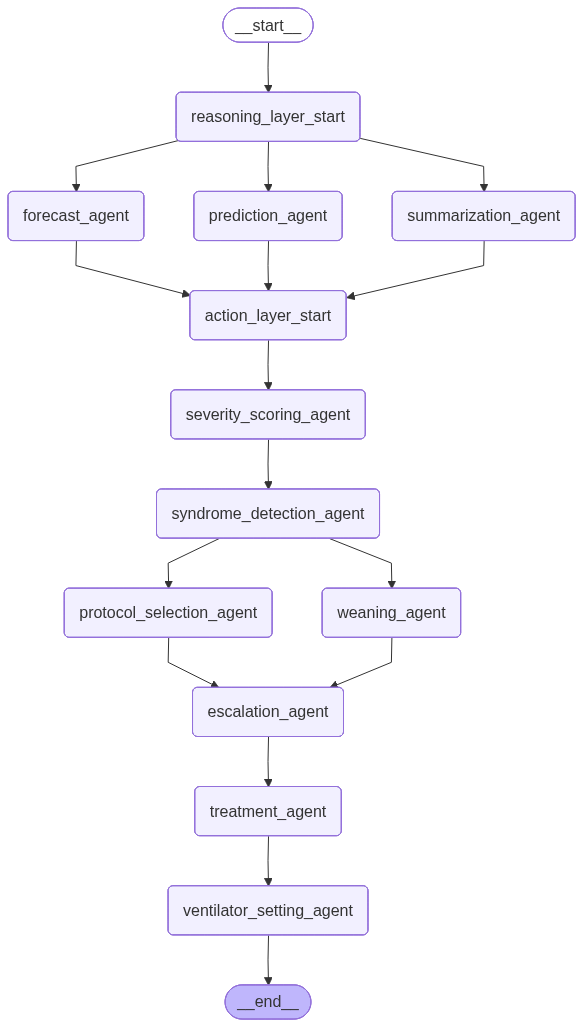

In [5]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode 
from langgraph.prebuilt import tools_condition

builder=StateGraph(OverallState)
builder.add_node("reasoning_layer_start",start_agent)
builder.add_node("forecast_agent",forecast_agent)
builder.add_node("prediction_agent",prediction_agent)
builder.add_node("summarization_agent",summarization_agent)
builder.add_node("action_layer_start",action_agent)
builder.add_node("severity_scoring_agent", severity_scoring_agent)
builder.add_node("syndrome_detection_agent", syndrome_detection_agent)
builder.add_node("protocol_selection_agent", protocol_selection_agent)
builder.add_node("escalation_agent", escalation_agent)
builder.add_node("treatment_agent", treatment_agent)
builder.add_node("ventilator_setting_agent", ventilator_setting_agent)
builder.add_node("weaning_agent", weaning_agent)
builder.add_edge(START,"reasoning_layer_start")
builder.add_edge("reasoning_layer_start","forecast_agent")
builder.add_edge("reasoning_layer_start","summarization_agent")
builder.add_edge("reasoning_layer_start","prediction_agent")
builder.add_edge("forecast_agent","action_layer_start")
builder.add_edge("prediction_agent","action_layer_start")
builder.add_edge("summarization_agent","action_layer_start")
builder.add_edge("action_layer_start", "severity_scoring_agent")
builder.add_edge("severity_scoring_agent", "syndrome_detection_agent")
builder.add_edge("syndrome_detection_agent", "protocol_selection_agent")
builder.add_edge("syndrome_detection_agent", "weaning_agent")
builder.add_edge("protocol_selection_agent", "escalation_agent")
builder.add_edge("weaning_agent", "escalation_agent")
builder.add_edge("escalation_agent", "treatment_agent")
builder.add_edge("treatment_agent", "ventilator_setting_agent")
builder.add_edge("ventilator_setting_agent", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
test_state = {

    "messages": [],

    # =========================
    # Static patient data
    # =========================
    "original_static": {
        "intime": "2180-05-03 14:20:00",
        "outtime": "2180-05-10 11:15:00",
        "gender": "M",
        "anchor_year": "2180",
        "anchor_age": "67",
        "insurance": "Medicare",
        "language": "English",
        "marital_status": "Married",
        "race": "White",
        "first_careunit": "MICU",
        "pbw_kg": "70",
        "height_inch": "68",
        "elixhauser_vanwalraven": "12"
    },

    # =========================
    # SEVERE VITAL SIGNS
    # =========================
    "original_vitals": {
        "heart_rate": 132,      # tachycardia
        "sbp": 78,              # hypotension
        "dbp": 45,
        "mbp": 55,              # shock threshold <65
        "temperature": 39.2,    # fever
        "sbp_ni": 75,
        "dbp_ni": 40,
        "mbp_ni": 52,
        "spO2": 82,             # severe hypoxia
        "glucose": 220          # stress hyperglycemia
    },

    # =========================
    # SEVERE LABS
    # =========================
    "original_labs": {
        "pH": 7.21,             # severe acidosis
        "pCO2": 68,             # respiratory failure
        "pO2": 55,              # severe hypoxemia
        "calculated_bicarbonate": 18,
        "so2": 80
    },

    # =========================
    # Neurological deterioration
    # =========================
    "original_gcs": {
        "gcs": 9,               # neurological impairment
        "gcs_motor": 4,
        "gcs_verbal": 2,
        "gcs_eyes": 3,
        "gcs_unable": 0,
        "sofa_24_hours": 9      # severe organ failure
    },

    # =========================
    # Ventilator settings showing distress
    # =========================
    "original_ventilator": {
        "ppeak": 35,
        "set_peep1": 12,        # high PEEP
        "total_peep": 12,
        "rr": 30,
        "set_rr1": 30,
        "total_rr": 30,
        "set_tv1": 500,
        "total_tv": 500,
        "set_fio21": 80,        # very high oxygen requirement
        "set_ie_ratio1": 1,
        "set_pc1": 20,
        "_set_pc_draeger": 0,
        "_pinsp_draeger2": 0,
        "_pinsp_hamilton2": 0,
        "_pcv_level2": 0
    },

    # =========================
    # Currently insufficient support
    # =========================
    "original_interventions": {
        "invasive": 0,
        "noninvasive": 1,
        "highflow": 0,
        "vasopressor": 0,
        "crrt": 0
    },

    # =========================
    # Outcomes
    # =========================
    "original_outcomes": {},

    "previous_forecasted_vitals": None,
    "previous_clinical_summary": None,
    "previous_outcomes": None,

    "forecasted_vitals": None,
    "outcomes": None,
    "clinical_summary": None,

    "severity_scores": None,
    "detected_syndromes": None,
    "selected_protocols": None,
    "escalation_decision": None,

    "recommended_ventilator_changes": None,
    "recommended_interventions": None,

    "improvement_detected": None,

    "supervisor_retry_count": 0,
    "supervisor_decision": None,
}

result = graph.invoke(test_state)



--- Forecasted Vitals ---
heart_rate=96.5 sbp=82.4 dbp=47.3 mbp=56.8 temperature=36.3 sbp_ni=80.2 dbp_ni=45.1 mbp_ni=56.9 spO2=95.2 glucose=247.8 sofa_24_hours=7.380333333333334

--- Predicted Outcomes ---
discharge_outcome=False icuouttime_outcome=True death_outcome=False sepsis_outcome=False los_outcome=285.9741045265625

--- Clinical Summary ---
 The patient is a male who was admitted to the ICU on May 3, 2021 at 2:20 PM and discharged on May 10, 2021 at 11:15 AM. He has Medicare insurance, speaks English, is married, and Caucasian race. His height is 68 inches (or 173 cm) and his weight is 70 pounds (or 31.75 kg). The patient has the following Elixhauser comorbidities: van Walraven syndrome, congestive heart failure (CHF), hypertension (HTN), chronic pulmonary obstructive disease (COPD), diabetes mellitus, obesity, and smoking.

--- Final Recommended Interventions (for dashboard) ---
{'invasive': 0, 'noninvasive': 1, 'highflow': 0, 'vasopressor': 1, 'crrt': 0}

--- Noninvasive Ven